# Week 4 · Lab — Memetic Algorithms for the TSP and a Toy Evolutionary Architecture Search

**Goals**
- Build a **memetic algorithm** (GA + local search; Moscato 1989) for a 100-city TSP: order crossover (OX) or edge
  recombination (ERX) followed by 2-opt with don't-look bits, in **Lamarckian** and **Baldwinian** variants.
- Compare it with a plain GA and with multistart 2-opt at an **equal evaluation budget** over several seeds, with
  an explicit and honest cost model for delta evaluations.
- Build a miniature **tabular NAS benchmark**: every configuration of a small NumPy MLP on a synthetic 3-class
  problem is trained once and cached, so search algorithms can be compared exactly (regret against the true best).
- Implement **regularised (aging) evolution** (Real et al. 2019) and compare it with a GA and random search,
  validating random search against its exact order-statistics formula.

**Prerequisites:** Notebooks 1–2 of this week (selection, OX/ERX), Week 1 (2-opt), basic neural networks
(forward/backward pass, Adam).

In [1]:
import sys; sys.path.insert(0, "..")
import numpy as np
import matplotlib.pyplot as plt
from utils import set_style, savefig, check_close, check_true
set_style()
rng = np.random.default_rng(0)
import itertools
import time
from collections import deque
from math import comb
from scipy import stats
from utils import PALETTE, random_euclidean_tsp, tour_length, held_karp, bhh_constant_estimate, best_so_far_on_grid

## Part A — Memetic algorithms for the TSP

### A.1 Mechanisms and cost model

A **memetic algorithm** (Moscato 1989; Merz & Freisleben 1997 for the TSP) applies a local search to every
offspring. Two ways to use the improved solution $\mathrm{LS}(x)$:

* **Lamarckian**: the genotype is *replaced* by $\mathrm{LS}(x)$ (acquired traits are inherited);
* **Baldwinian** (Hinton & Nowlan 1987): the fitness is $f(\mathrm{LS}(x))$ but the genotype stays $x$ — learning
  smooths the fitness landscape without being written back.

```text
memetic GA (steady state, Lamarckian):
    P <- N tours, each = 2opt(random permutation)
    until the budget is exhausted:
        p1, p2 <- binary tournament (distinct)
        c <- crossover(p1, p2)                      # OX or ERX
        c <- 2opt(c, start from endpoints of edges not present in p1 or p2)
        if c is shorter than the worst tour and its length is not already in P: replace the worst
```

**2-opt with don't-look bits** (Bentley 1992): a queue holds the cities whose incident edges changed; for a queued
city both incident edges are tested against all other edges with the delta
$\Delta = D_{ac} + D_{bd} - D_{ab} - D_{cd}$ (edges $(a,b)$, $(c,d)$ replaced by $(a,c)$, $(b,d)$), the best
improving move is applied, and its four endpoints are re-queued. The search terminates (every move strictly shortens
the tour, and without a move the queue shrinks), and every edge of the final tour was tested against all other
edges *after it was created*. That is **not** quite a guarantee of 2-opt local optimality: the 2-opt move for a pair
of edges $e, f$ depends on which endpoints lie on the same side of the cycle, and a later move that reverses a
path running between $e$ and $f$ changes that pairing — and hence the delta of $(e, f)$ — without queueing any of
their endpoints. Don't-look bits are therefore a (very good) heuristic approximation of a full 2-opt descent;
Section A.2 exhibits a failure on a non-metric instance, and a single final full scan restores the guarantee
(Exercise 1).

**Cost model.** A full tour evaluation reads $n$ distances; a 2-opt delta reads 4. We therefore charge a full
evaluation **1 unit** and a delta evaluation **$4/n$ units** ($0.04$ for $n = 100$), i.e. we count distance
lookups normalised to full evaluations. Counting a delta as a full evaluation would make any local-search method
look $n/4 = 25$ times more expensive than it is — this choice must always be stated when comparing memetic
algorithms with plain evolutionary ones. Wall-clock times are reported alongside.

In [2]:
def two_opt_ls(t, D, queue=None):
    """2-opt local search with don't-look bits. Returns (tour, number of delta evaluations)."""
    t = np.array(t); n = len(t)
    pos = np.empty(n, int); pos[t] = np.arange(n)
    q = deque(range(n) if queue is None else queue)
    inq = np.zeros(n, bool); inq[list(q)] = True
    deltas, ar = 0, np.arange(n)
    while q:
        x = q.popleft(); inq[x] = False
        for p in (pos[x], (pos[x] - 1) % n):              # the edge leaving x and the edge entering x
            nxt = np.roll(t, -1)
            a, b = t[p], nxt[p]
            delta = D[a, t] + D[b, nxt] - D[a, b] - D[t, nxt]
            delta[[(p - 1) % n, p, (p + 1) % n]] = np.inf  # edges sharing a city: no valid move
            deltas += n - 3
            k = int(np.argmin(delta))
            if delta[k] < -1e-10:
                c, d = t[k], nxt[k]
                lo, hi = (p + 1, k) if p < k else (k + 1, p)
                t[lo:hi + 1] = t[lo:hi + 1][::-1]; pos[t[lo:hi + 1]] = ar[lo:hi + 1]
                for y in (a, b, c, d):
                    if not inq[y]:
                        q.append(y); inq[y] = True
                break
    return t, deltas


def ox_batch(P1, P2, rng, cuts=None):
    """Order crossover (Davis 1985) for a batch of parent pairs, fully vectorised."""
    B, n = P1.shape
    if cuts is None:
        cuts = np.sort(np.argsort(rng.random((B, n + 1)), axis=1)[:, :2], axis=1)
    a, b = cuts[:, 0], cuts[:, 1]
    pos = np.arange(n)
    inseg_pos = (pos >= a[:, None]) & (pos < b[:, None])
    inseg_city = np.zeros((B, n), bool)
    np.put_along_axis(inseg_city, P1, inseg_pos, axis=1)
    slots = (b[:, None] + pos) % n                        # positions b, b+1, ... (cyclic): non-segment slots first
    rot = np.take_along_axis(P2, slots, 1)                # p2 read from position b onwards
    keep = ~np.take_along_axis(inseg_city, rot, 1)
    fill = np.take_along_axis(rot, np.argsort(~keep, axis=1, kind="stable"), 1)
    child = P1.copy()
    k = pos[None, :] < (n - (b - a))[:, None]
    child[np.nonzero(k)[0], slots[k]] = fill[k]
    return child


def ox_reference(p1, p2, a, b):
    """Textbook OX, written independently with Python lists (used only for validation)."""
    n = len(p1)
    child = [None] * n
    child[a:b] = list(p1[a:b])
    seg = set(p1[a:b])
    fill = [c for c in list(p2[b:]) + list(p2[:b]) if c not in seg]
    for i, c in zip([(b + k) % n for k in range(n - (b - a))], fill):
        child[i] = c
    return np.array(child)


def erx(p1, p2, rng):
    """Edge recombination (Whitley, Starkweather & Fuquay 1989), as in Notebook 2."""
    n = len(p1)
    adj = [set() for _ in range(n)]
    for p in (p1.tolist(), p2.tolist()):
        for i in range(n):
            adj[p[i]].add(p[i - 1]); adj[p[i - 1]].add(p[i])
    c = int(p1[0] if rng.random() < 0.5 else p2[0])
    child, unvisited = [c], set(range(n)) - {c}
    u = rng.random(n)
    for step in range(1, n):
        for nb in adj[c]:
            adj[nb].discard(c)
        if adj[c]:
            dmin = min(len(adj[x]) for x in adj[c])
            ties = [x for x in adj[c] if len(adj[x]) == dmin]
            c = ties[int(u[step] * len(ties))]
        else:
            rest = sorted(unvisited)
            c = rest[int(u[step] * len(rest))]
        child.append(c); unvisited.discard(c)
    return np.array(child)

### A.2 Validation

* the 2-opt delta formula against recomputing the tour length after the move (via `utils.tour_length`);
* the local-search output is a 2-opt local optimum on random Euclidean instances — checked by brute force over all
  $\binom n2$ reversals evaluated from scratch — and, as a counterexample to over-claiming, *not* on one
  non-metric random symmetric instance;
* the vectorised OX equals an independent list-based implementation for the same cut points;
* on a 12-city instance the memetic algorithm finds the Held–Karp optimum.

In [3]:
_, D30 = random_euclidean_tsp(30, np.random.default_rng(1))
ok = True
for _ in range(300):
    t = rng.permutation(30); i, j = np.sort(rng.choice(np.arange(1, 29), 2, replace=False))
    a, b, c, d = t[i], t[i + 1], t[j], t[(j + 1) % 30]
    t2 = np.r_[t[:i + 1], t[i + 1:j + 1][::-1], t[j + 1:]]
    ok &= np.isclose(tour_length(t2, D30) - tour_length(t, D30), D30[a, c] + D30[b, d] - D30[a, b] - D30[c, d])
check_true(ok, "2-opt delta formula = recomputed tour-length difference (300 random moves)")
lo_ok = True
for s in range(6):
    t, _ = two_opt_ls(rng.permutation(30), D30)
    L0 = tour_length(t, D30)
    best_nb = min(tour_length(np.r_[t[:i + 1], t[i + 1:j + 1][::-1], t[j + 1:]], D30)
                  for i in range(30) for j in range(i + 1, 30))
    lo_ok &= best_nb >= L0 - 1e-9 and sorted(t) == list(range(30))
check_true(lo_ok, "don't-look-bit 2-opt returns a 2-opt local optimum on Euclidean instances (brute force, 6 starts)")
g_ce = np.random.default_rng(4023)                          # non-metric symmetric instance, n = 11
Dn = g_ce.random((11, 11)); Dn = Dn + Dn.T; np.fill_diagonal(Dn, 0.0)
t_ce, _ = two_opt_ls(g_ce.permutation(11), Dn)
best_ce = min(tour_length(np.r_[t_ce[:i + 1], t_ce[i + 1:j + 1][::-1], t_ce[j + 1:]], Dn)
              for i in range(11) for j in range(i + 1, 11))
print(f"non-metric counterexample: don't-look-bit result {tour_length(t_ce, Dn):.4f}, best 2-opt neighbour {best_ce:.4f}")
check_true(best_ce < tour_length(t_ce, Dn) - 1e-9,
           "don't-look bits are a heuristic: on this non-metric instance an improving 2-opt move remains")
Pa = np.array([rng.permutation(30) for _ in range(200)]); Pb = np.array([rng.permutation(30) for _ in range(200)])
cuts = np.sort(np.array([rng.choice(31, 2, replace=False) for _ in range(200)]), axis=1)
Cv = ox_batch(Pa, Pb, rng, cuts)
check_true(all(np.array_equal(Cv[r], ox_reference(Pa[r], Pb[r], *cuts[r])) for r in range(200)),
           "vectorised OX = reference OX on 200 random pairs")

[PASS] 2-opt delta formula = recomputed tour-length difference (300 random moves)


[PASS] don't-look-bit 2-opt returns a 2-opt local optimum on Euclidean instances (brute force, 6 starts)
non-metric counterexample: don't-look-bit result 6.3159, best 2-opt neighbour 5.8286
[PASS] don't-look bits are a heuristic: on this non-metric instance an improving 2-opt move remains
[PASS] vectorised OX = reference OX on 200 random pairs


In [4]:
def edge_set(t):
    u = np.roll(t, -1)
    return set(zip(np.minimum(t, u).tolist(), np.maximum(t, u).tolist()))


def memetic(D, rng, budget, N=10, xover="OX", mode="lamarck"):
    """Steady-state memetic GA. Returns (best tour length, trace of (units, best), best tour)."""
    n = len(D); cost_delta = 4.0 / n
    units = 0.0
    def ls(t, queue=None):
        nonlocal units
        t2, d = two_opt_ls(t, D, queue)
        units += 1 + d * cost_delta
        return t2
    geno, fit = [], []
    trace = []
    for _ in range(N):
        g = rng.permutation(n); imp = ls(g)
        geno.append(imp if mode == "lamarck" else g); fit.append(tour_length(imp, D))
        trace.append((units, min(fit)))
    fit = np.array(fit)
    best = fit.min()
    best_tour = geno[int(np.argmin(fit))] if mode == "lamarck" else two_opt_ls(geno[int(np.argmin(fit))], D)[0]
    while units < budget:
        i1, i2 = rng.choice(N, 2, replace=False), rng.choice(N, 2, replace=False)
        a, b = geno[i1[np.argmin(fit[i1])]], geno[i2[np.argmin(fit[i2])]]
        c = ox_batch(a[None], b[None], rng)[0] if xover == "OX" else erx(a, b, rng)
        if mode == "lamarck":                              # queue only the endpoints of foreign edges
            foreign = edge_set(c) - (edge_set(a) | edge_set(b))
            q = sorted({x for e in foreign for x in e})
            imp = ls(c, q)
            g = imp
        else:                                              # Baldwinian: full local search, genotype unchanged
            imp = ls(c); g = c
        if units > budget:                                 # this child overran the budget: discard it
            break
        fc = tour_length(imp, D)
        w = np.argmax(fit)
        if fc < fit[w] and not np.any(np.isclose(fit, fc)):
            geno[w], fit[w] = g, fc
        if fc < best:
            best, best_tour = fc, imp
        trace.append((units, best))
    return best, np.array(trace), best_tour


_, D12 = random_euclidean_tsp(12, np.random.default_rng(5))
opt12, _ = held_karp(D12)
m12 = min(memetic(D12, np.random.default_rng(s), budget=300)[0] for s in range(3))
check_close(m12, opt12, "memetic GA reaches the Held-Karp optimum on a 12-city instance", atol=1e-9)

[PASS] memetic GA reaches the Held-Karp optimum on a 12-city instance: got 3.734869, expected 3.734869


### A.3 The contenders

* **Plain GA**: population 100, binary tournament, vectorised OX ($p_c = 0.9$), inversion mutation with
  probability $0.1$, 1-elitism; every child costs one full evaluation.
* **Multistart 2-opt**: independent descents from random tours until the budget is spent.
* **Memetic, Lamarckian** with OX and with ERX; **memetic, Baldwinian** with OX (population 10).

Budget $B = 60{,}000$ units, 6 seeds, one random uniform 100-city instance. A local search that would end beyond the
budget is discarded, so no method is credited with work it could not pay for.

Note that the Lamarckian child is repaired from a *partial* queue (the endpoints of its foreign edges), the
Merz–Freisleben heuristic: an improving move between two inherited edges can be missed, so the child is not
guaranteed to be a 2-opt local optimum. This is part of what makes Lamarckian offspring cheap; the Baldwinian
variant cannot use it because its genotype is not locally optimal.

In [5]:
def plain_ga(D, rng, budget, N=100, pc=0.9, pm=0.1):
    n = len(D)
    cost = lambda T: D[T, np.roll(T, -1, axis=1)].sum(1)
    P = np.array([rng.permutation(n) for _ in range(N)]); f = cost(P); units = N
    best = f.min(); trace = [(units, best)]
    pos = np.arange(n)
    while units + N <= budget:
        T = rng.integers(0, N, (N, 2, 2))
        win = np.take_along_axis(T, np.argmin(f[T], 2)[..., None], 2)[..., 0]
        A, Bp = P[win[:, 0]], P[win[:, 1]]
        C = np.where((rng.random(N) < pc)[:, None], ox_batch(A, Bp, rng), A)
        ij = np.sort(np.argsort(rng.random((N, n)), axis=1)[:, :2], axis=1)
        inv = (pos >= ij[:, :1]) & (pos <= ij[:, 1:]) & (rng.random((N, 1)) < pm)
        C = np.take_along_axis(C, np.where(inv, ij[:, :1] + ij[:, 1:] - pos, pos), 1)   # reverse [i, j]
        fc = cost(C); units += N
        if f.min() < fc.min():
            w = np.argmax(fc); C[w] = P[np.argmin(f)]; fc[w] = f.min()
        P, f = C, fc
        best = min(best, f.min()); trace.append((units, best))
    return best, np.array(trace), P[np.argmin(f)]


def multistart_2opt(D, rng, budget):
    n = len(D); units, best, trace, tour = 0.0, np.inf, [], None
    while units < budget:
        t, d = two_opt_ls(rng.permutation(n), D)
        units += 1 + d * 4.0 / n
        if units > budget:                                 # the last descent overran the budget: discard it
            break
        if tour_length(t, D) < best:
            best, tour = tour_length(t, D), t
        trace.append((units, best))
    return best, np.array(trace), tour


pts100, D100 = random_euclidean_tsp(100, np.random.default_rng(2024))
BUDGET, SEEDS = 60_000, 6
contenders = {
    "plain GA (OX + inversion)": lambda g: plain_ga(D100, g, BUDGET),
    "multistart 2-opt": lambda g: multistart_2opt(D100, g, BUDGET),
    "memetic OX, Lamarckian": lambda g: memetic(D100, g, BUDGET, xover="OX", mode="lamarck"),
    "memetic ERX, Lamarckian": lambda g: memetic(D100, g, BUDGET, xover="ERX", mode="lamarck"),
    "memetic OX, Baldwinian": lambda g: memetic(D100, g, BUDGET, xover="OX", mode="baldwin"),
}
tsp_res, wall = {}, {}
for name, run in contenders.items():
    t0 = time.perf_counter()
    tsp_res[name] = [run(np.random.default_rng(100 + s)) for s in range(SEEDS)]
    wall[name] = (time.perf_counter() - t0) / SEEDS
ms_desc = np.mean([len(r[1]) for r in tsp_res["multistart 2-opt"]])
print(f"multistart 2-opt: {ms_desc:.1f} descents per run on average, i.e. about {BUDGET / ms_desc:,.0f} units each")
print(f"BHH asymptotic estimate 0.7124 sqrt(n A) = {bhh_constant_estimate(100):.3f} (boundary effects make finite-n tours longer)")
print(f"{'algorithm':28s} best length: median [IQR]      wall s/run")
fin = {}
for name, rr in tsp_res.items():
    v = np.array([r[0] for r in rr]); fin[name] = v
    print(f"{name:28s} {np.median(v):.4f} [{np.percentile(v, 25):.4f}, {np.percentile(v, 75):.4f}]   {wall[name]:6.2f}")

multistart 2-opt: 38.5 descents per run on average, i.e. about 1,558 units each
BHH asymptotic estimate 0.7124 sqrt(n A) = 7.124 (boundary effects make finite-n tours longer)
algorithm                    best length: median [IQR]      wall s/run
plain GA (OX + inversion)    23.2135 [22.6259, 23.7958]     2.90
multistart 2-opt             8.3430 [8.3066, 8.3685]     1.65
memetic OX, Lamarckian       8.0315 [8.0271, 8.0442]     2.74
memetic ERX, Lamarckian      8.0386 [8.0276, 8.0467]     2.89
memetic OX, Baldwinian       8.2440 [8.1907, 8.3298]     2.01


**Reading the results.** The plain GA is hopeless at this budget (tours about three times longer than a 2-opt
local optimum): with no problem knowledge, 60,000 evaluations are a vanishing fraction of $99!/2$ tours. A single
2-opt descent costs about $1{,}500$ units, so multistart 2-opt gets roughly 40 independent local optima; the
Lamarckian memetic algorithm spends the first 10 descents building its population and then recombines local
optima, and each child needs only a short repair around its few foreign edges — many more (and better) local
optima per unit of budget. OX and ERX perform alike here: after local search the heritability difference seen in
Notebook 2 matters much less. The Baldwinian variant pays for a *full* descent for every child because its
genotypes are never improved, so it sees far fewer children and ends between multistart and Lamarckian.
Wall-clock times per run are of the same order for all local-search methods, so the conclusions do not hinge on
the cost model.

In [6]:
for other in ("multistart 2-opt", "plain GA (OX + inversion)", "memetic OX, Baldwinian"):
    p = stats.wilcoxon(fin["memetic OX, Lamarckian"], fin[other], alternative="less").pvalue
    check_true(p < 0.05, f"Lamarckian memetic (OX) beats {other} on paired seeds (Wilcoxon p = {p:.3f})")

[PASS] Lamarckian memetic (OX) beats multistart 2-opt on paired seeds (Wilcoxon p = 0.016)
[PASS] Lamarckian memetic (OX) beats plain GA (OX + inversion) on paired seeds (Wilcoxon p = 0.016)
[PASS] Lamarckian memetic (OX) beats memetic OX, Baldwinian on paired seeds (Wilcoxon p = 0.016)


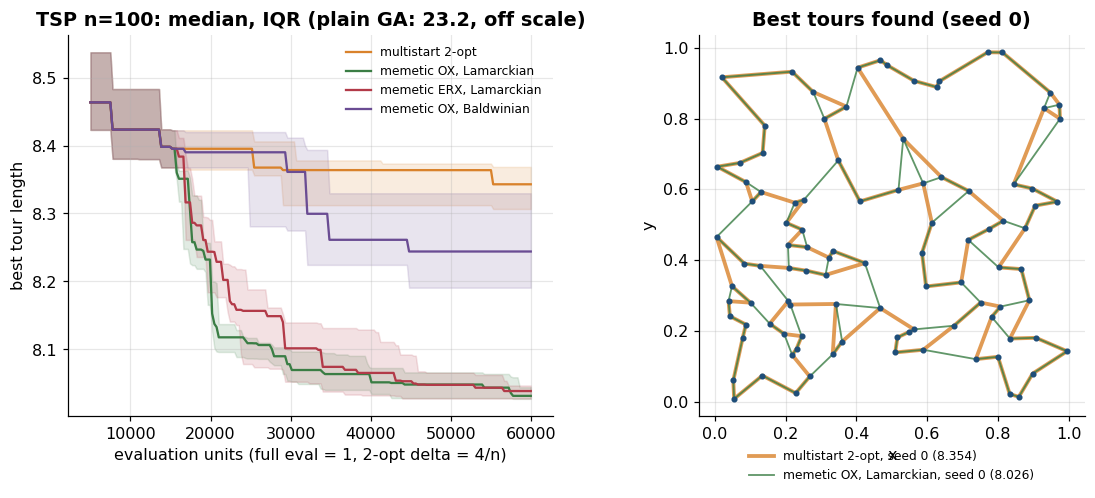

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.5))
grid = np.linspace(5_000, BUDGET, 200)
for (name, rr), col in zip(tsp_res.items(), PALETTE.values()):
    if name.startswith("plain GA"):
        continue                                           # far off the scale (see table)
    Y = np.array([best_so_far_on_grid(r[1][:, 0], r[1][:, 1], grid) for r in rr])
    ax[0].plot(grid, np.median(Y, 0), color=col, label=name)
    ax[0].fill_between(grid, *np.nanpercentile(Y, [25, 75], 0), color=col, alpha=0.15)
ax[0].set(xlabel="evaluation units (full eval = 1, 2-opt delta = 4/n)", ylabel="best tour length",
          title=f"TSP n=100: median, IQR (plain GA: {np.median(fin['plain GA (OX + inversion)']):.1f}, off scale)")
ax[0].legend(fontsize=8)
for name, col, lw in (("multistart 2-opt", PALETTE["orange"], 2.5), ("memetic OX, Lamarckian", PALETTE["green"], 1.2)):
    t_disp = tsp_res[name][0][2]
    tt = np.r_[t_disp, t_disp[0]]
    ax[1].plot(pts100[tt, 0], pts100[tt, 1], "-", color=col, lw=lw, alpha=0.8,
               label=f"{name}, seed 0 ({tour_length(t_disp, D100):.3f})")
ax[1].plot(pts100[:, 0], pts100[:, 1], "o", ms=3, color=PALETTE["blue"])
ax[1].set(title="Best tours found (seed 0)", aspect="equal", xlabel="x", ylabel="y")
ax[1].legend(loc="upper center", bbox_to_anchor=(0.5, -0.06), fontsize=8)
savefig("w4_memetic_tsp.png"); plt.show()

## Part B — A toy evolutionary architecture and hyperparameter search

Neural architecture search by evolution (Real et al. 2017; **regularised evolution**, Real et al. 2019, which
produced AmoebaNet) and population-based hyperparameter tuning are among the most visible modern uses of
evolutionary algorithms. Evaluations are expensive (a training run each), so the comparison unit is — exactly as
in this course — the number of evaluations. **Tabular benchmarks** such as NAS-Bench-101 (Ying et al. 2019)
pre-compute every configuration once so that search algorithms can be compared cheaply and exactly; we build a
miniature one.

**Task.** Three interleaved noisy spirals in 2-D (300 training, 900 validation points). **Model.** A NumPy MLP
trained full-batch with Adam for 100 steps from a fixed initialisation seed, so each configuration has one
deterministic validation cross-entropy. **Search space** ($3\cdot3\cdot2\cdot4\cdot3 = 216$ configurations):
depth $\in\lbrace1,2,3\rbrace$, width $\in\lbrace8,16,32\rbrace$, activation $\in\lbrace\tanh,\mathrm{ReLU}\rbrace$,
learning rate $\in\lbrace0.003,0.01,0.03,0.1\rbrace$, $L_2$ penalty $\in\lbrace0,10^{-4},10^{-3}\rbrace$.

In [8]:
def spirals(n_per, K, rng, noise=0.5):
    X, y = [], []
    for k in range(K):
        r = np.linspace(0.05, 1, n_per)
        th = np.linspace(2 * np.pi * k / K, 2 * np.pi * k / K + 5.0, n_per) + noise * rng.standard_normal(n_per)
        X.append(np.c_[r * np.sin(th), r * np.cos(th)]); y.append(np.full(n_per, k))
    X, y = np.concatenate(X), np.concatenate(y)
    p = rng.permutation(len(y))
    return X[p], y[p]

drng = np.random.default_rng(0)
Xtr, ytr = spirals(100, 3, drng)
Xva, yva = spirals(300, 3, drng)
SPACE = {"depth": [1, 2, 3], "width": [8, 16, 32], "act": ["tanh", "relu"], "lr": [0.003, 0.01, 0.03, 0.1],
         "l2": [0.0, 1e-4, 1e-3]}
GENES = list(SPACE)
CARD = [len(SPACE[g]) for g in GENES]


def forward(X, W, B, act):
    H = [X]
    for i, (w, b) in enumerate(zip(W, B)):
        z = H[-1] @ w + b
        H.append(z if i == len(W) - 1 else (np.tanh(z) if act == "tanh" else np.maximum(z, 0)))
    return H


def train_mlp(depth, width, act, lr, l2, steps=100, seed=0):
    """Full-batch Adam on softmax cross-entropy; returns (W, B)."""
    r = np.random.default_rng(seed)
    sizes = [2] + [width] * depth + [3]
    W = [r.standard_normal((a, b)) * np.sqrt((2.0 if act == "relu" else 1.0) / a) for a, b in zip(sizes[:-1], sizes[1:])]
    B = [np.zeros(b) for b in sizes[1:]]
    params = W + B
    m = [np.zeros_like(p) for p in params]; v = [np.zeros_like(p) for p in params]
    Y = np.eye(3)[ytr]
    for t in range(1, steps + 1):
        H = forward(Xtr, W, B, act)
        z = H[-1] - H[-1].max(1, keepdims=True); P = np.exp(z); P /= P.sum(1, keepdims=True)
        G = (P - Y) / len(ytr)
        gW, gB = [None] * len(W), [None] * len(W)
        for i in range(len(W) - 1, -1, -1):
            gW[i] = H[i].T @ G + l2 * W[i]; gB[i] = G.sum(0)
            if i > 0:
                G = G @ W[i].T
                G = G * (1 - H[i] ** 2) if act == "tanh" else G * (H[i] > 0)
        for k, (p, g) in enumerate(zip(params, gW + gB)):
            m[k] = 0.9 * m[k] + 0.1 * g; v[k] = 0.999 * v[k] + 0.001 * g * g
            p -= lr * (m[k] / (1 - 0.9**t)) / (np.sqrt(v[k] / (1 - 0.999**t)) + 1e-8)
    return W, B


def val_loss(W, B, act):
    h = forward(Xva, W, B, act)[-1]
    z = h - h.max(1, keepdims=True)
    lp = z - np.log(np.exp(z).sum(1, keepdims=True))
    return float(-lp[np.arange(len(yva)), yva].mean()), float((h.argmax(1) == yva).mean())

**Gradient check.** Before trusting 216 training runs we verify the hand-written backward pass against central
finite differences of the training loss (an independent computation) for one small network of each activation.

In [9]:
def train_loss(W, B, act, l2):
    h = forward(Xtr, W, B, act)[-1]
    z = h - h.max(1, keepdims=True)
    lp = z - np.log(np.exp(z).sum(1, keepdims=True))
    return -lp[np.arange(len(ytr)), ytr].mean() + 0.5 * l2 * sum((w**2).sum() for w in W)

for act in ("tanh", "relu"):
    r = np.random.default_rng(3)
    W = [r.standard_normal((2, 5)), r.standard_normal((5, 3))]; B = [r.standard_normal(5) * 0.1, np.zeros(3)]
    H = forward(Xtr, W, B, act)
    z = H[-1] - H[-1].max(1, keepdims=True); P = np.exp(z); P /= P.sum(1, keepdims=True)
    G = (P - np.eye(3)[ytr]) / len(ytr)
    g_out = H[1].T @ G + 1e-3 * W[1]
    G1 = G @ W[1].T; G1 = G1 * (1 - H[1] ** 2) if act == "tanh" else G1 * (H[1] > 0)
    g_in = H[0].T @ G1 + 1e-3 * W[0]
    num = np.zeros_like(W[0]); eps = 1e-6
    for idx in np.ndindex(W[0].shape):
        Wp = [W[0].copy(), W[1]]; Wm = [W[0].copy(), W[1]]
        Wp[0][idx] += eps; Wm[0][idx] -= eps
        num[idx] = (train_loss(Wp, B, act, 1e-3) - train_loss(Wm, B, act, 1e-3)) / (2 * eps)
    check_close(np.abs(g_in - num).max(), 0.0, f"backprop vs finite differences ({act}), max abs error", atol=1e-6)

[PASS] backprop vs finite differences (tanh), max abs error: got 0.0, expected 0.0
[PASS] backprop vs finite differences (relu), max abs error: got 0.0, expected 0.0


In [10]:
t0 = time.perf_counter()
TABLE = {}
for idx in itertools.product(*[range(c) for c in CARD]):
    cfg = [SPACE[g][i] for g, i in zip(GENES, idx)]
    W, B = train_mlp(*cfg)
    TABLE[idx] = val_loss(W, B, cfg[2])
print(f"trained and cached all {len(TABLE)} configurations in {time.perf_counter() - t0:.1f} s")
keys = list(TABLE)
losses = np.array([TABLE[k][0] for k in keys])
order = np.argsort(losses)
best_key = keys[order[0]]
print("best configuration:", {g: SPACE[g][i] for g, i in zip(GENES, best_key)},
      f"val loss {TABLE[best_key][0]:.4f}, val accuracy {TABLE[best_key][1]:.3f}")
print(f"median val loss {np.median(losses):.3f}; 3rd-best value (top 1.4% of the space) {np.sort(losses)[2]:.4f}")

trained and cached all 216 configurations in 30.9 s
best configuration: {'depth': 2, 'width': 16, 'act': 'tanh', 'lr': 0.1, 'l2': 0.0001} val loss 0.1969, val accuracy 0.943
median val loss 0.468; 3rd-best value (top 1.4% of the space) 0.2035


### B.1 Search algorithms over the cached table

Each algorithm may evaluate **20 distinct configurations** (9% of the space); repeated queries hit the cache and
are free, as in any sensible NAS implementation. Regret = best validation loss found $-$ best in the whole space.

* **Random search** — sampling without replacement (Bergstra & Bengio 2012 showed it is a strong baseline).
* **GA** — population 8, binary tournament, uniform crossover on the 5 genes, each gene resampled with
  probability $1/5$, generational with 1-elitism.
* **Regularised (aging) evolution** (Real et al. 2019):

```text
population <- queue of P random configurations (evaluated)
while budget remains:
    S <- sample s members uniformly from population
    parent <- best of S                         # tournament selection
    child <- parent with ONE gene changed to a different value
    evaluate child; push child to the back of the queue
    pop the OLDEST member from the front         # aging, not the worst
```

* **Non-aging evolution**: identical, but the *worst* member is removed — the ablation Real et al. used to show
  that aging acts as a regulariser (every configuration must keep being re-discovered to survive, which favours
  regions that are robustly good).

We use $P = 8$, $s = 3$ (scaled down from $P = 100$, $s = 25$ in the paper to our 20-evaluation budget).

In [11]:
class Oracle:
    """Counts distinct evaluations against the cached table; raises StopIteration at the budget."""
    def __init__(self, budget):
        self.budget, self.seen, self.trace, self.best = budget, set(), [], np.inf
    def __call__(self, key):
        key = tuple(int(k) for k in key)
        if key not in self.seen:
            if len(self.seen) >= self.budget:
                raise StopIteration
            self.seen.add(key)
            self.best = min(self.best, TABLE[key][0]); self.trace.append(self.best)
        return TABLE[key][0]


def rand_key(rng):
    return tuple(int(rng.integers(c)) for c in CARD)


def random_search(orc, rng):
    for i in rng.permutation(len(keys)):
        orc(keys[i])


def ga_search(orc, rng, N=8, max_gen=500):
    P = [rand_key(rng) for _ in range(N)]
    f = np.array([orc(k) for k in P])
    for _ in range(max_gen):
        kids = [P[int(np.argmin(f))]]                         # elitism
        while len(kids) < N:
            i, j = rng.integers(N, size=2), rng.integers(N, size=2)
            a, b = P[i[np.argmin(f[i])]], P[j[np.argmin(f[j])]]
            c = [a[g] if rng.random() < 0.5 else b[g] for g in range(len(CARD))]
            c = tuple(int(rng.integers(CARD[g])) if rng.random() < 1 / len(CARD) else c[g] for g in range(len(CARD)))
            kids.append(c)
        P = kids; f = np.array([orc(k) for k in P])


def mutate_one(key, rng):
    g = int(rng.integers(len(CARD)))
    new = int(rng.integers(CARD[g] - 1)); new += new >= key[g]       # a different value for gene g
    return key[:g] + (new,) + key[g + 1:]


def evolution(orc, rng, P=8, s=3, aging=True, max_steps=5000):
    pop = deque()
    while len(pop) < P:
        k = rand_key(rng); pop.append((k, orc(k)))
    for _ in range(max_steps):
        S = [pop[i] for i in rng.choice(len(pop), s, replace=False)]
        parent = min(S, key=lambda e: e[1])[0]
        child = mutate_one(parent, rng)
        pop.append((child, orc(child)))
        if aging:
            pop.popleft()
        else:
            pop.remove(max(pop, key=lambda e: e[1]))


def run_search(algo, seed, budget=20, **kw):
    orc = Oracle(budget)
    try:
        algo(orc, np.random.default_rng(seed), **kw)
    except StopIteration:
        pass
    tr = np.array(orc.trace)
    return np.r_[tr, np.full(budget - len(tr), tr[-1])] - losses.min()   # regret after each evaluation

BUD_NAS, REPS = 20, 400
searchers = {"random search": (random_search, {}), "GA": (ga_search, {}),
             "regularised evolution (aging)": (evolution, {"aging": True}),
             "evolution, remove worst": (evolution, {"aging": False})}
regret = {name: np.array([run_search(a, 1000 + s, BUD_NAS, **kw) for s in range(REPS)]) for name, (a, kw) in searchers.items()}

**Validation of random search against its exact law.** Sampling $B$ of $M$ configurations without replacement,
the best found is the $r$-th best overall with probability $\binom{M-r}{B-1}/\binom{M}{B}$, so the exact expected
regret is $\sum_r \binom{M-r}{B-1}\binom{M}{B}^{-1}\,(\ell_{(r)} - \ell_{(1)})$.

In [12]:
M = len(keys); sl = np.sort(losses)
for Bq in (5, 10, 20):
    pr = np.array([comb(M - r, Bq - 1) / comb(M, Bq) for r in range(1, M + 1)])
    exact = pr @ (sl - sl[0])
    sim = regret["random search"][:, Bq - 1]
    check_close(pr.sum(), 1.0, f"order-statistic probabilities sum to 1 (B={Bq})", atol=1e-12)
    check_true(abs(sim.mean() - exact) < 4 * sim.std() / np.sqrt(REPS),
               f"random search, B={Bq}: simulated mean regret {sim.mean():.4f} = exact {exact:.4f} (4 SE)")

print(f"\n{'algorithm':32s} regret after 20 evals: mean ± SE      P(found the best)   P(top-3)")
for name, Rg in regret.items():
    fr = Rg[:, -1]
    top3 = np.mean(fr <= sl[2] - sl[0] + 1e-12)
    print(f"{name:32s} {fr.mean():.4f} ± {fr.std() / np.sqrt(REPS):.4f}            {np.mean(fr == 0):5.2f}            {top3:5.2f}")

[PASS] order-statistic probabilities sum to 1 (B=5): got 1.0, expected 1.0
[PASS] random search, B=5: simulated mean regret 0.0662 = exact 0.0674 (4 SE)
[PASS] order-statistic probabilities sum to 1 (B=10): got 1.0, expected 1.0
[PASS] random search, B=10: simulated mean regret 0.0299 = exact 0.0305 (4 SE)
[PASS] order-statistic probabilities sum to 1 (B=20): got 1.0, expected 1.0
[PASS] random search, B=20: simulated mean regret 0.0143 = exact 0.0139 (4 SE)

algorithm                        regret after 20 evals: mean ± SE      P(found the best)   P(top-3)
random search                    0.0143 ± 0.0009             0.10             0.29
GA                               0.0105 ± 0.0007             0.15             0.38
regularised evolution (aging)    0.0115 ± 0.0008             0.14             0.38
evolution, remove worst          0.0106 ± 0.0007             0.14             0.38


In [13]:
for name in ("regularised evolution (aging)", "GA"):
    p = stats.mannwhitneyu(regret[name][:, -1], regret["random search"][:, -1], alternative="less").pvalue
    print(f"{name} vs random search, one-sided Mann-Whitney p = {p:.2e}")
p_re = stats.mannwhitneyu(regret["regularised evolution (aging)"][:, -1], regret["random search"][:, -1], alternative="less").pvalue
check_true(p_re < 0.01, "regularised evolution has lower final regret than random search (p < 0.01)")

regularised evolution (aging) vs random search, one-sided Mann-Whitney p = 5.89e-05
GA vs random search, one-sided Mann-Whitney p = 5.10e-05
[PASS] regularised evolution has lower final regret than random search (p < 0.01)


**Reading the results.** All three evolutionary searches reach a lower final regret than random search (by
20–27% on average, and they find one of the top-3 configurations in about 38% of the runs versus 29%),
while the differences *between* the GA, aging and non-aging evolution are within their standard errors at this
tiny budget. That is consistent with Real et al. (2019), whose advantage for aging appeared in large, noisy search
spaces with thousands of evaluations; Exercise 5 asks you to add evaluation noise. The right panel shows why local
variation helps: good configurations form a connected region of the space (depth $\ge 2$ with learning rate
$\ge 0.01$),
so mutating one gene of a good configuration is much more likely to produce another good one than sampling
uniformly.

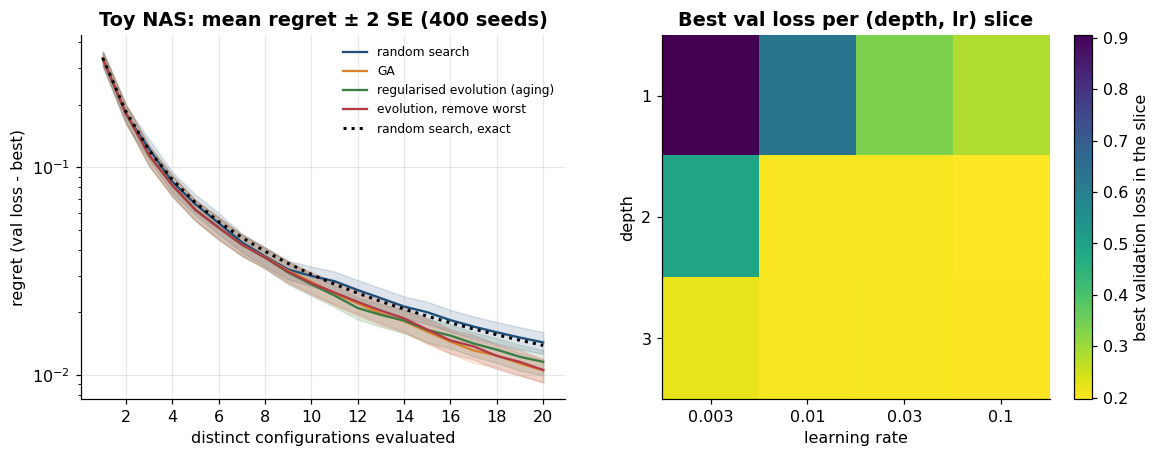

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.3))
ev = np.arange(1, BUD_NAS + 1)
for (name, Rg), col in zip(regret.items(), PALETTE.values()):
    mu, se = Rg.mean(0), Rg.std(0) / np.sqrt(REPS)
    ax[0].plot(ev, mu, color=col, label=name)
    ax[0].fill_between(ev, mu - 2 * se, mu + 2 * se, color=col, alpha=0.15)
exact_curve = [np.array([comb(M - r, b - 1) / comb(M, b) for r in range(1, M + 1)]) @ (sl - sl[0]) for b in ev]
ax[0].plot(ev, exact_curve, "k:", lw=2, label="random search, exact")
ax[0].set(yscale="log", xlabel="distinct configurations evaluated", ylabel="regret (val loss - best)",
          title="Toy NAS: mean regret ± 2 SE (400 seeds)")
ax[0].set_xticks(np.arange(2, BUD_NAS + 1, 2))
ax[0].legend(fontsize=8)
depth_i = np.array([k[0] for k in keys]); lr_i = np.array([k[3] for k in keys])
Z = np.array([[losses[(depth_i == d) & (lr_i == l)].min() for l in range(4)] for d in range(3)])
im = ax[1].imshow(Z, cmap="viridis_r", aspect="auto")
ax[1].set_xticks(range(4), SPACE["lr"]); ax[1].set_yticks(range(3), SPACE["depth"])
ax[1].set(xlabel="learning rate", ylabel="depth", title="Best val loss per (depth, lr) slice")
ax[1].grid(False)
plt.colorbar(im, ax=ax[1], label="best validation loss in the slice")
savefig("w4_nas_toy.png"); plt.show()

## Key takeaways

- On the TSP, a GA without problem knowledge is far behind 2-opt; adding 2-opt to every offspring (memetic,
  Lamarckian) beats both plain GA and multistart 2-opt at an equal, explicitly defined budget: recombination of
  local optima is a better restart distribution than a random permutation.
- Lamarckian inheritance wins over Baldwinian here because writing the local optimum back makes offspring cheap to
  polish (only the few foreign edges must be repaired); the Baldwin effect helps when local search is cheap
  relative to the budget or when writing back destroys diversity.
- The evaluation cost model (a delta costs $4/n$ of a full evaluation) is part of the result and must be reported.
- A tabular benchmark makes hyperparameter/architecture search experiments exact and cheap; regularised evolution
  is a two-line modification of tournament-based evolution (remove the oldest, mutate one gene); it and the other
  evolutionary searches beat random search on this toy space, with the random-search baseline validated against
  its exact order-statistics law.

## Exercises

1. ★ Prove that 2-opt with don't-look bits terminates. Then make the failure mode of Section A.1 precise: show
   that reversing a path that runs between two untouched edges $e, f$ changes the reconnection (and the delta) of
   the pair $(e, f)$, and propose a modification that provably ends in a 2-opt local optimum at the cost of one extra
   full neighbourhood scan per descent.
2. ★ Derive the exact expected regret of random search *with* replacement and compare it with the without-
   replacement formula for $B = 20$, $M = 216$. When does the difference matter?
3. ★★ Replace 2-opt by Or-opt (segment moves of length 1–3) and by 2-opt + Or-opt in the memetic algorithm, with
   the same cost model. Which gives the best tour at 60,000 units?
4. ★★ Implement the distance-preserving crossover DPX (Freisleben & Merz 1996): the child contains exactly the
   edges common to both parents, reconnected greedily with edges absent from both. Measure its heritability and
   compare it with OX and ERX inside the memetic algorithm.
5. ★★ In the toy NAS, add a *noisy* evaluation (validation loss of a single training run with a random seed) and
   compare aging vs non-aging evolution. Real et al. (2019) argue that aging is most useful under noise — do you
   observe it?
6. ★★★ Extend the search space with a per-layer width (an architecture of variable length) and implement a
   mutation that inserts or deletes a layer. Build the new tabular benchmark and study how the advantage of
   regularised evolution over random search scales with the size of the space.